In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [4]:
df = pd.read_csv('/kaggle/input/credit-card-fraud-detection-dataset-2023/creditcard_2023.csv')
df

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-0.260648,-0.469648,2.496266,-0.083724,0.129681,0.732898,0.519014,-0.130006,0.727159,...,-0.110552,0.217606,-0.134794,0.165959,0.126280,-0.434824,-0.081230,-0.151045,17982.10,0
1,1,0.985100,-0.356045,0.558056,-0.429654,0.277140,0.428605,0.406466,-0.133118,0.347452,...,-0.194936,-0.605761,0.079469,-0.577395,0.190090,0.296503,-0.248052,-0.064512,6531.37,0
2,2,-0.260272,-0.949385,1.728538,-0.457986,0.074062,1.419481,0.743511,-0.095576,-0.261297,...,-0.005020,0.702906,0.945045,-1.154666,-0.605564,-0.312895,-0.300258,-0.244718,2513.54,0
3,3,-0.152152,-0.508959,1.746840,-1.090178,0.249486,1.143312,0.518269,-0.065130,-0.205698,...,-0.146927,-0.038212,-0.214048,-1.893131,1.003963,-0.515950,-0.165316,0.048424,5384.44,0
4,4,-0.206820,-0.165280,1.527053,-0.448293,0.106125,0.530549,0.658849,-0.212660,1.049921,...,-0.106984,0.729727,-0.161666,0.312561,-0.414116,1.071126,0.023712,0.419117,14278.97,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
568625,568625,-0.833437,0.061886,-0.899794,0.904227,-1.002401,0.481454,-0.370393,0.189694,-0.938153,...,0.167503,0.419731,1.288249,-0.900861,0.560661,-0.006018,3.308968,0.081564,4394.16,1
568626,568626,-0.670459,-0.202896,-0.068129,-0.267328,-0.133660,0.237148,-0.016935,-0.147733,0.483894,...,0.031874,0.388161,-0.154257,-0.846452,-0.153443,1.961398,-1.528642,1.704306,4653.40,1
568627,568627,-0.311997,-0.004095,0.137526,-0.035893,-0.042291,0.121098,-0.070958,-0.019997,-0.122048,...,0.140788,0.536523,-0.211100,-0.448909,0.540073,-0.755836,-0.487540,-0.268741,23572.85,1
568628,568628,0.636871,-0.516970,-0.300889,-0.144480,0.131042,-0.294148,0.580568,-0.207723,0.893527,...,-0.060381,-0.195609,-0.175488,-0.554643,-0.099669,-1.434931,-0.159269,-0.076251,10160.83,1


In [5]:
print(df.head())

   id        V1        V2        V3        V4        V5        V6        V7  \
0   0 -0.260648 -0.469648  2.496266 -0.083724  0.129681  0.732898  0.519014   
1   1  0.985100 -0.356045  0.558056 -0.429654  0.277140  0.428605  0.406466   
2   2 -0.260272 -0.949385  1.728538 -0.457986  0.074062  1.419481  0.743511   
3   3 -0.152152 -0.508959  1.746840 -1.090178  0.249486  1.143312  0.518269   
4   4 -0.206820 -0.165280  1.527053 -0.448293  0.106125  0.530549  0.658849   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0 -0.130006  0.727159  ... -0.110552  0.217606 -0.134794  0.165959  0.126280   
1 -0.133118  0.347452  ... -0.194936 -0.605761  0.079469 -0.577395  0.190090   
2 -0.095576 -0.261297  ... -0.005020  0.702906  0.945045 -1.154666 -0.605564   
3 -0.065130 -0.205698  ... -0.146927 -0.038212 -0.214048 -1.893131  1.003963   
4 -0.212660  1.049921  ... -0.106984  0.729727 -0.161666  0.312561 -0.414116   

        V26       V27       V28    Amount  C

In [6]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568630 entries, 0 to 568629
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   id      568630 non-null  int64  
 1   V1      568630 non-null  float64
 2   V2      568630 non-null  float64
 3   V3      568630 non-null  float64
 4   V4      568630 non-null  float64
 5   V5      568630 non-null  float64
 6   V6      568630 non-null  float64
 7   V7      568630 non-null  float64
 8   V8      568630 non-null  float64
 9   V9      568630 non-null  float64
 10  V10     568630 non-null  float64
 11  V11     568630 non-null  float64
 12  V12     568630 non-null  float64
 13  V13     568630 non-null  float64
 14  V14     568630 non-null  float64
 15  V15     568630 non-null  float64
 16  V16     568630 non-null  float64
 17  V17     568630 non-null  float64
 18  V18     568630 non-null  float64
 19  V19     568630 non-null  float64
 20  V20     568630 non-null  float64


In [7]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 568630
Number of columns: 31


In [8]:
missing_values = df.isnull().sum()
print("Missing values per column")
print(missing_values)

Missing values per column
id        0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


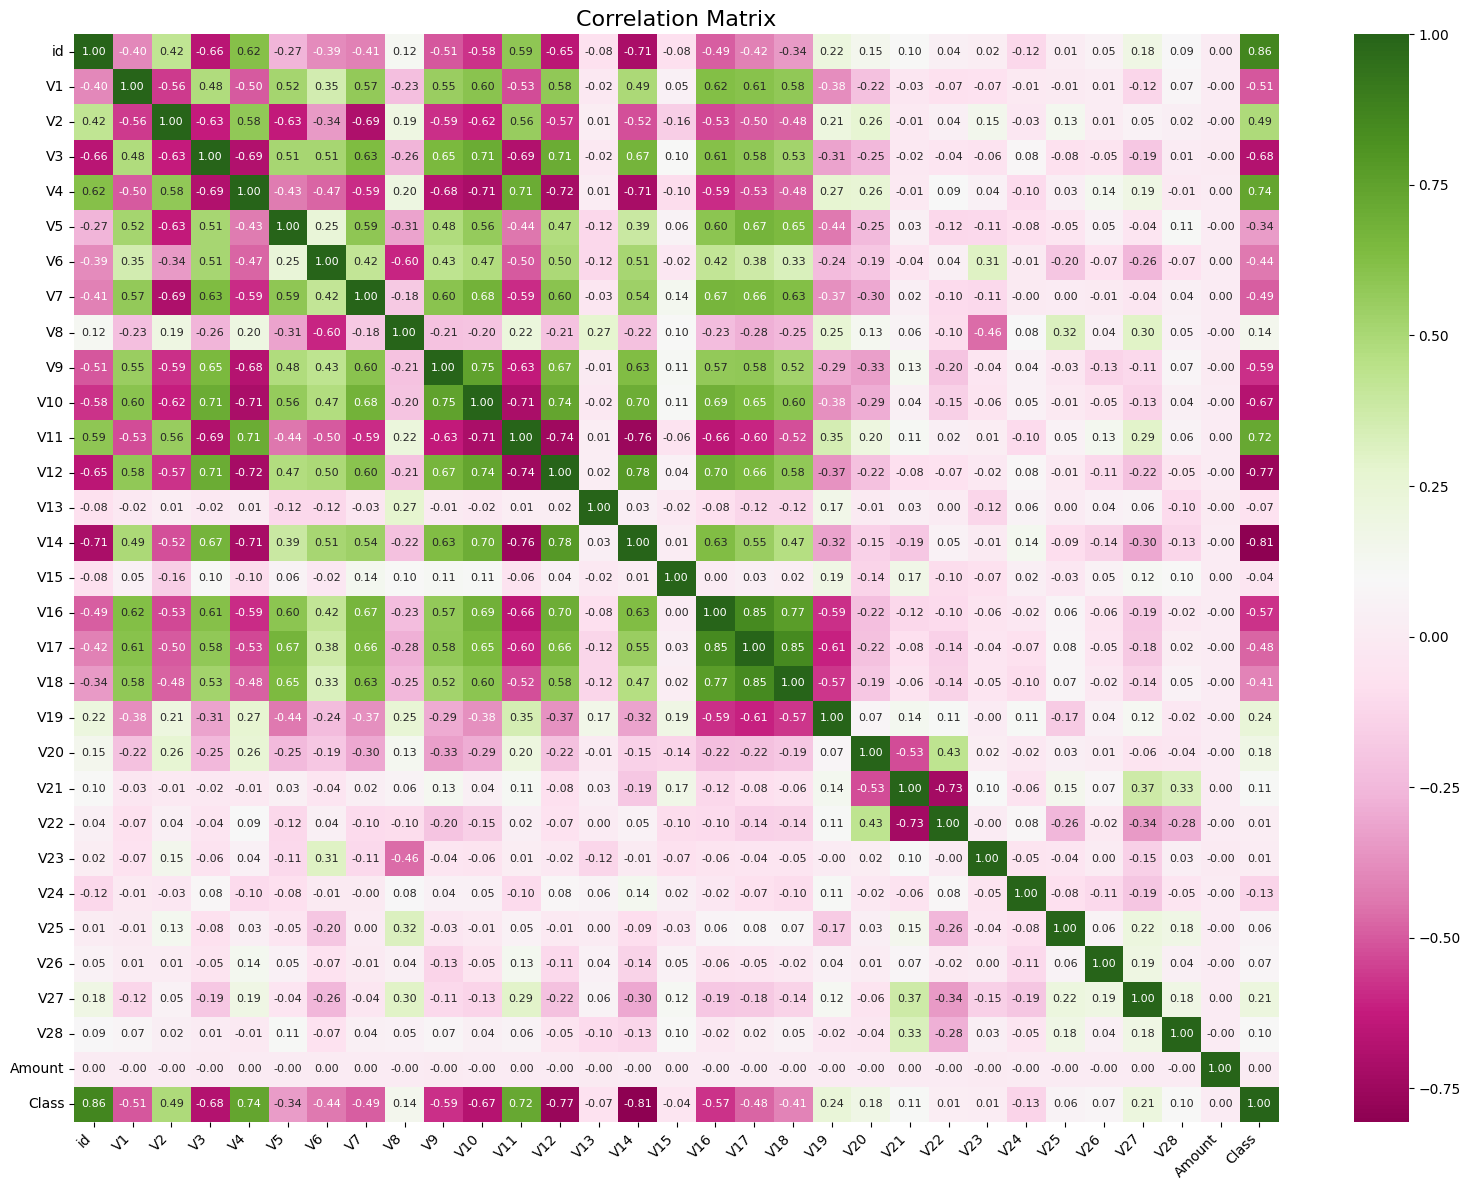

In [12]:
correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='PiYG', 
            annot_kws={'size': 8})  # Font boyutunu küçült
plt.title('Correlation Matrix', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [13]:
df.describe()

,id,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,568630.000000,5.686300e+05,5.686300e+05,5.686300e+05,568630.000000,5.686300e+05,5.686300e+05,568630.000000,568630.000000,568630.000000,...,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,5.686300e+05,568630.000000,5.686300e+05,5.686300e+05,568630.000000,568630.0
mean,284314.500000,-5.118237e-17,-1.023647e-16,1.023647e-16,0.000000,2.559118e-17,2.559118e-17,0.000000,0.000000,0.000000,...,1.279559e-17,1.599449e-18,6.397796e-18,-2.559118e-17,-3.838678e-17,0.000000,-2.559118e-17,3.838678e-17,12041.957635,0.5
std,164149.486121,1.000001e+00,1.000001e+00,1.000001e+00,1.000001,1.000001e+00,1.000001e+00,1.000001,1.000001,1.000001,...,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001,1.000001e+00,1.000001e+00,6919.644449,0.5
min,0.000000,-3.495584e+00,-4.996657e+01,-3.183760e+00,-4.951222,-9.952786e+00,-2.111111e+01,-4.351839,-10.756342,-3.751919,...,-1.938252e+01,-7.734798e+00,-3.029545e+01,-4.067968e+00,-1.361263e+01,-8.226969,-1.049863e+01,-3.903524e+01,50.010000,0.0
25%,142157.250000,-5.652859e-01,-4.866777e-01,-6.492987e-01,-0.656020,-2.934955e-01,-4.458712e-01,-0.283533,-0.192257,-0.568745,...,-1.664408e-01,-4.904892e-01,-2.376289e-01,-6.515801e-01,-5.541485e-01,-0.631895,-3.049607e-01,-2.318783e-01,6054.892500,0.0
50%,284314.500000,-9.363846e-02,-1.358939e-01,3.528579e-04,-0.073762,8.108788e-02,7.871758e-02,0.233366,-0.114524,0.092526,...,-3.743065e-02,-2.732881e-02,-5.968903e-02,1.590123e-02,-8.193162e-03,-0.011892,-1.729111e-01,-1.392973e-02,12030.150000,0.5
75%,426471.750000,8.326582e-01,3.435552e-01,6.285380e-01,0.707005,4.397368e-01,4.977881e-01,0.525955,0.047299,0.559262,...,1.479787e-01,4.638817e-01,1.557153e-01,7.007374e-01,5.500147e-01,0.672888,3.340230e-01,4.095903e-01,18036.330000,1.0
max,568629.000000,2.229046e+00,4.361865e+00,1.412583e+01,3.201536,4.271689e+01,2.616840e+01,217.873038,5.958040,20.270062,...,8.087080e+00,1.263251e+01,3.170763e+01,1.296564e+01,1.462151e+01,5.623285,1.132311e+02,7.725594e+01,24039.930000,1.0


In [14]:
df['Class'].unique()

array([0, 1])

In [16]:
print("Benzersiz Class sayısı:", df['Class'].nunique())
print(f"Toplam benzersiz Class sayısı: {len(df['Class'].unique())}")
print(f"Toplam satır sayısı: {len(df)}")

Benzersiz Class sayısı: 2
Toplam benzersiz Class sayısı: 2
Toplam satır sayısı: 568630


Class değerlerinin dağılımı:
Class
0    284315
1    284315
Name: count, dtype: int64

Class 0 sayısı: 284315
Class 1 sayısı: 284315

Yüzdelik dağılım:
Class
0    50.0
1    50.0
Name: proportion, dtype: float64


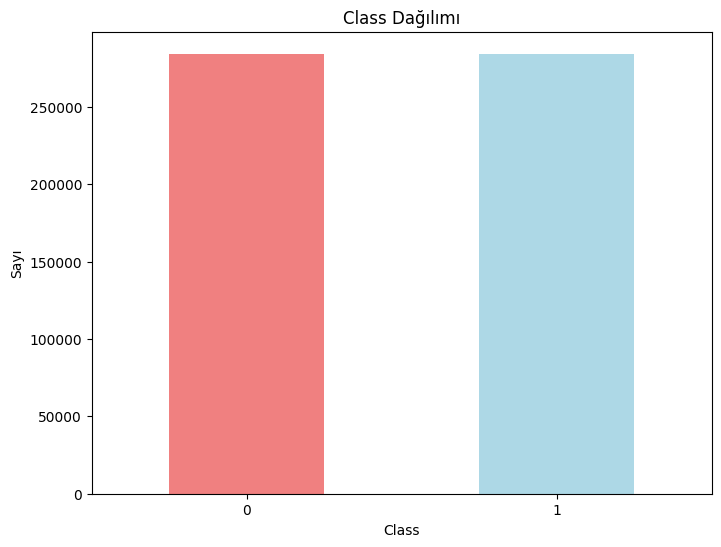

In [17]:
# Class sütunundaki 0 ve 1 değerlerinin sayısı
print("Class değerlerinin dağılımı:")
class_counts = df['Class'].value_counts()
print(class_counts)

print(f"\nClass 0 sayısı: {(df['Class'] == 0).sum()}")
print(f"Class 1 sayısı: {(df['Class'] == 1).sum()}")

# Yüzdelik olarak da gösterelim
print(f"\nYüzdelik dağılım:")
class_percentages = df['Class'].value_counts(normalize=True) * 100
print(class_percentages)

# Görselleştirme için
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
class_counts.plot(kind='bar', color=['lightcoral', 'lightblue'])
plt.title('Class Dağılımı')
plt.xlabel('Class')
plt.ylabel('Sayı')
plt.xticks(rotation=0)
plt.show()

In [18]:
X = df.drop('Class', axis=1)
y = df['Class']

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Decision Tree Model
print("=" * 50)
print("DECISION TREE CLASSIFIER")
print("=" * 50)

# Model oluştur ve eğit
dtree_model = DecisionTreeClassifier(random_state=42)
dtree_model.fit(X_train, y_train)

# Tahmin yap
dt_pred = dtree_model.predict(X_test)

DECISION TREE CLASSIFIER


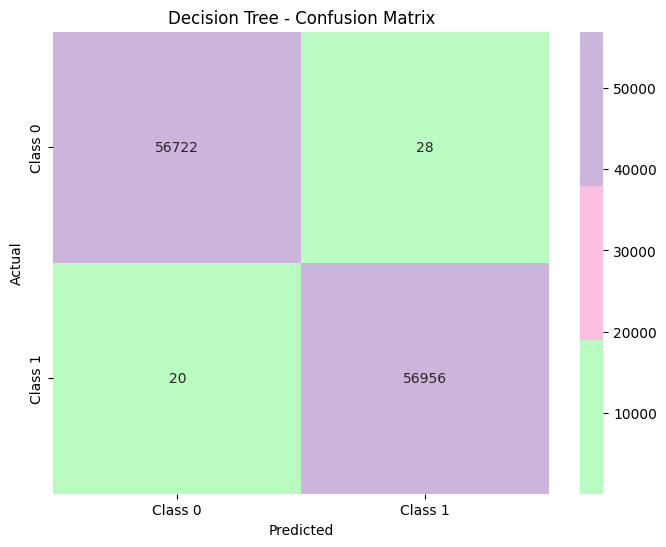

In [69]:
from matplotlib.colors import ListedColormap
custom_colors = ["#b9fbc0", "#f9c0e1", "#cdb4db"]  # pastel yeşil, pembe, lila
cmap = ListedColormap(custom_colors)
            
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, 
            xticklabels=['Class 0', 'Class 1'], 
            yticklabels=['Class 0', 'Class 1']) #vmin=-cm.max(), vmax=cm.max()*1.2, center=cm.max()/3
plt.title('Decision Tree - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [72]:
print("\n2. CLASSIFICATION REPORT:")
print("-" * 30)
print(classification_report(y_test, dt_pred))


2. CLASSIFICATION REPORT:
------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56750
           1       1.00      1.00      1.00     56976

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726



In [73]:
print("\n3. ACCURACY SCORE:")
print("-" * 20)
accuracy = accuracy_score(y_test, dt_pred)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

print("\n4. ADDITIONAL METRICS:")
print("-" * 25)
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, dt_pred)
recall = recall_score(y_test, dt_pred)
f1 = f1_score(y_test, dt_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

print("\n" + "=" * 50)


3. ACCURACY SCORE:
--------------------
Accuracy: 0.9996 (99.96%)

4. ADDITIONAL METRICS:
-------------------------
Precision: 0.9995
Recall: 0.9996
F1-Score: 0.9996



In [75]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

🤖 MACHINE LEARNING ALGORITHMS COMPARISON

📊 DECISION TREE
----------------------------------------
Accuracy: 0.9996 (99.96%)
Precision: 0.9995
Recall: 0.9996
F1-Score: 0.9996


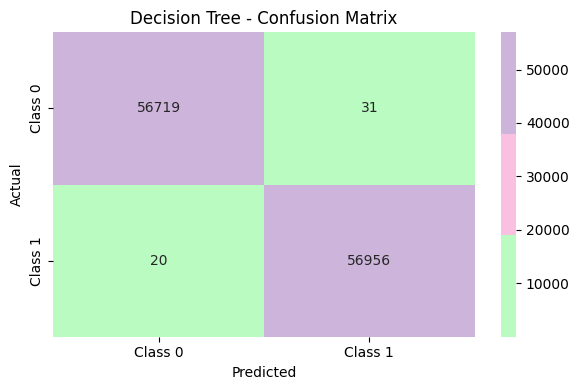


📊 RANDOM FOREST
----------------------------------------
Accuracy: 0.9998 (99.98%)
Precision: 0.9999
Recall: 0.9997
F1-Score: 0.9998


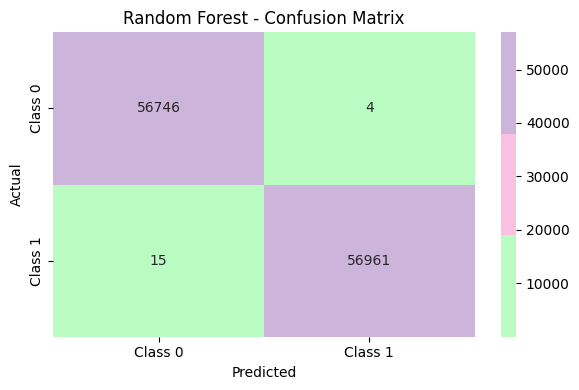


📊 SVM
----------------------------------------
Accuracy: 0.9997 (99.97%)
Precision: 0.9997
Recall: 0.9996
F1-Score: 0.9997


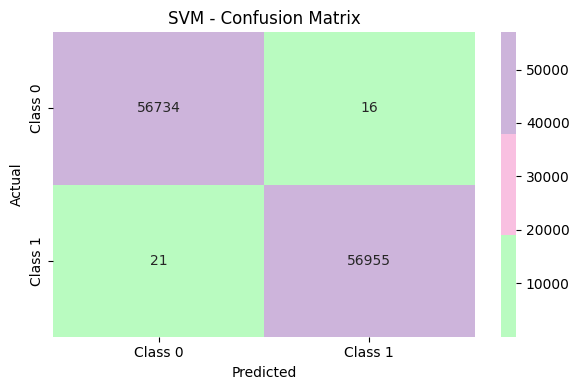


📊 LOGISTIC REGRESSION
----------------------------------------
Accuracy: 0.9984 (99.84%)
Precision: 0.9988
Recall: 0.9979
F1-Score: 0.9984


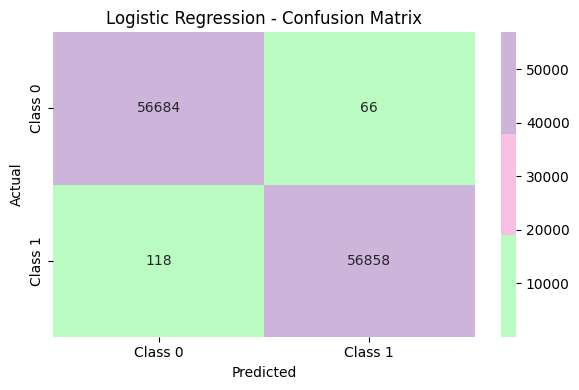


📊 K-NEAREST NEIGHBORS
----------------------------------------
Accuracy: 0.9994 (99.94%)
Precision: 0.9989
Recall: 0.9999
F1-Score: 0.9994


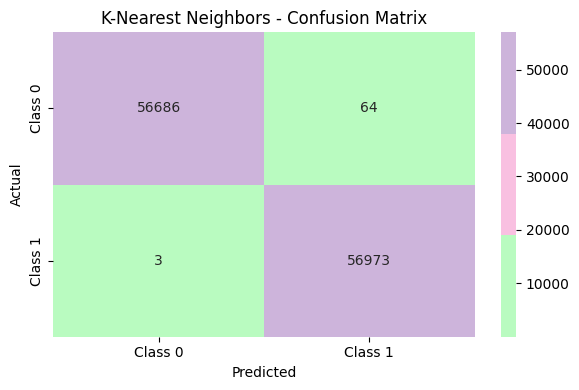


📊 NAIVE BAYES
----------------------------------------
Accuracy: 0.9314 (93.14%)
Precision: 0.9804
Recall: 0.8808
F1-Score: 0.9279


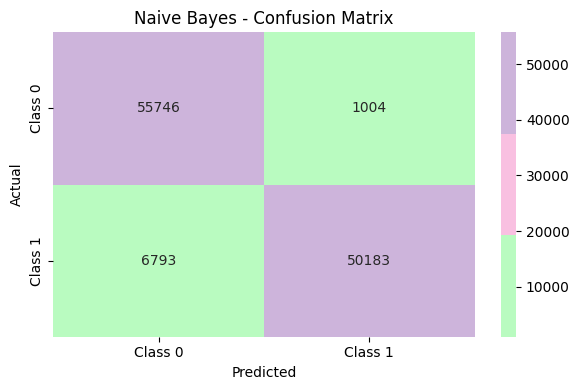


📊 GRADIENT BOOSTING
----------------------------------------
Accuracy: 0.9997 (99.97%)
Precision: 0.9997
Recall: 0.9997
F1-Score: 0.9997


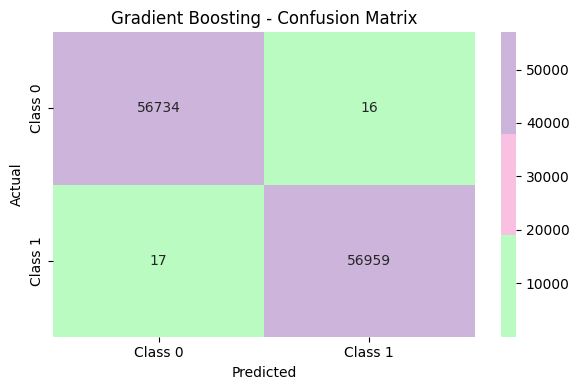


📊 NEURAL NETWORK
----------------------------------------
Accuracy: 0.9997 (99.97%)
Precision: 0.9997
Recall: 0.9997
F1-Score: 0.9997


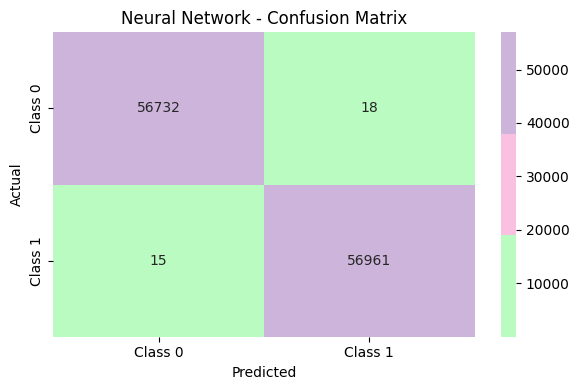


📈 OVERALL COMPARISON
              Model  Accuracy  Precision  Recall  F1-Score
      Decision Tree    0.9996     0.9995  0.9996    0.9996
      Random Forest    0.9998     0.9999  0.9997    0.9998
                SVM    0.9997     0.9997  0.9996    0.9997
Logistic Regression    0.9984     0.9988  0.9979    0.9984
K-Nearest Neighbors    0.9994     0.9989  0.9999    0.9994
        Naive Bayes    0.9314     0.9804  0.8808    0.9279
  Gradient Boosting    0.9997     0.9997  0.9997    0.9997
     Neural Network    0.9997     0.9997  0.9997    0.9997

🏆 BEST MODELS:
Best Accuracy: Random Forest (0.9998)
Best F1-Score: Random Forest (0.9998)


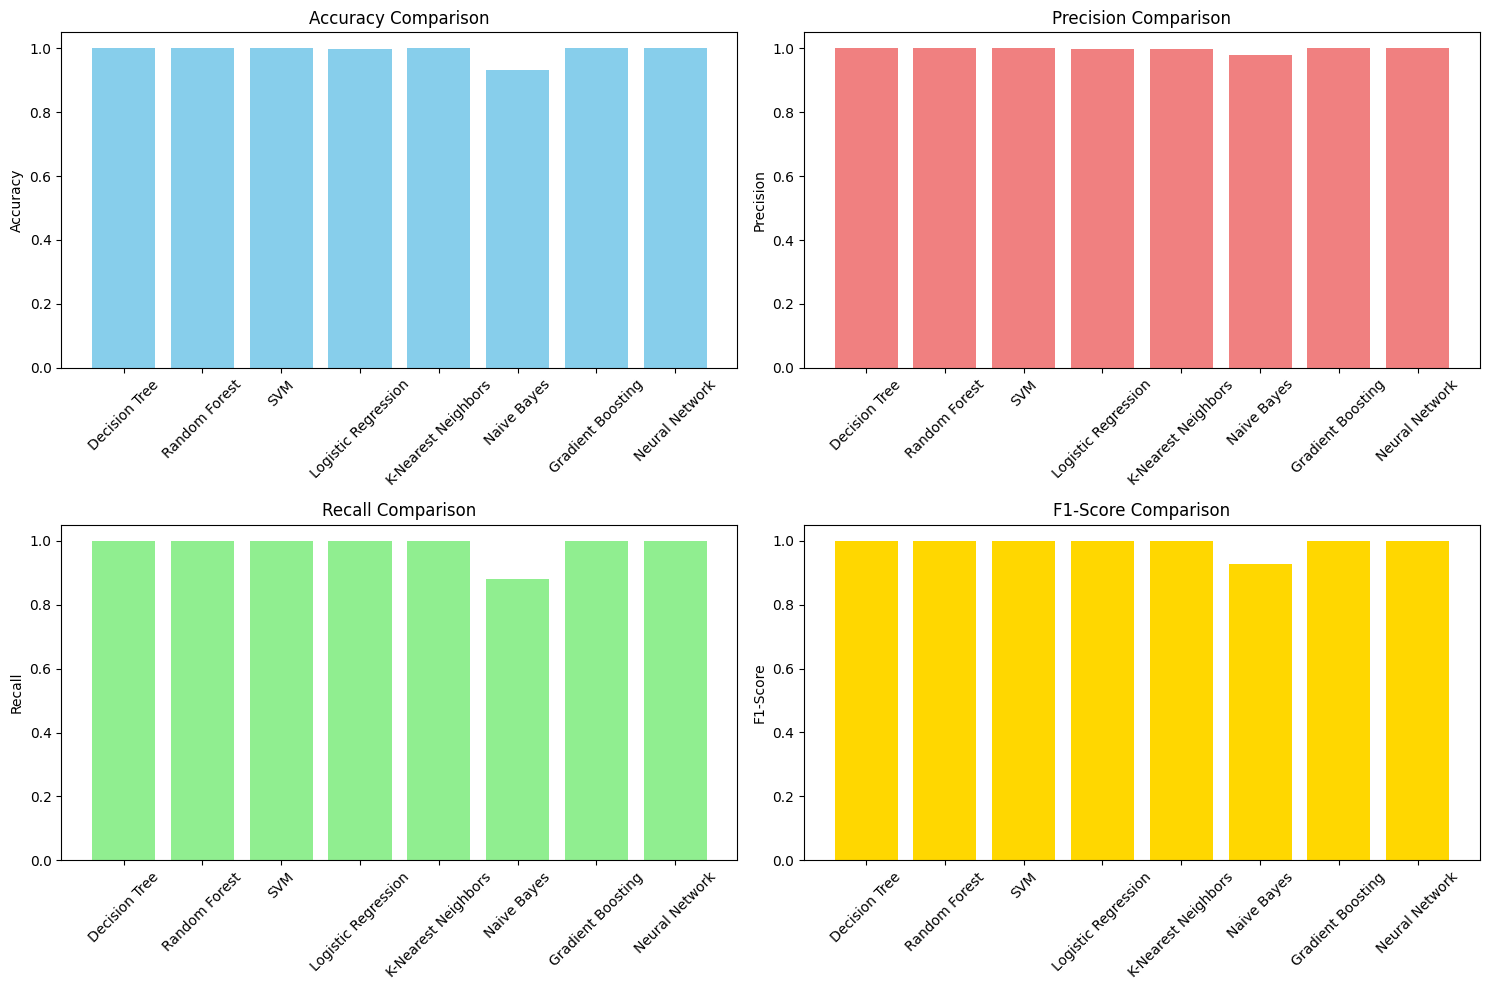

In [80]:
# Model listesi
models = {
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC(random_state=42),
    'Logistic Regression': LogisticRegression(),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'Neural Network': MLPClassifier()
}

# Sonuçları saklamak için
results = []

print("🤖 MACHINE LEARNING ALGORITHMS COMPARISON")
print("=" * 60)

for name, model in models.items():
    print(f"\n📊 {name.upper()}")
    print("-" * 40)
    
    # Model eğit
    model.fit(X_train, y_train)
    
    # Tahmin yap
    y_pred = model.predict(X_test)
    
    # Metrikleri hesapla
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Sonuçları kaydet
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })
    
    print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=['Class 0', 'Class 1'],
                yticklabels=['Class 0', 'Class 1']) #vmin=0, vmax=cm.max()*1.3, center=cm.max()/3)
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

# Sonuçları DataFrame'e çevir
results_df = pd.DataFrame(results)
results_df = results_df.round(4)

print("\n📈 OVERALL COMPARISON")
print("=" * 60)
print(results_df.to_string(index=False))

# En iyi modeli bul
best_accuracy = results_df.loc[results_df['Accuracy'].idxmax()]
best_f1 = results_df.loc[results_df['F1-Score'].idxmax()]

print(f"\n🏆 BEST MODELS:")
print(f"Best Accuracy: {best_accuracy['Model']} ({best_accuracy['Accuracy']:.4f})")
print(f"Best F1-Score: {best_f1['Model']} ({best_f1['F1-Score']:.4f})")

# Karşılaştırma grafiği
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Accuracy
axes[0,0].bar(results_df['Model'], results_df['Accuracy'], color='skyblue')
axes[0,0].set_title('Accuracy Comparison')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].tick_params(axis='x', rotation=45)

# Precision
axes[0,1].bar(results_df['Model'], results_df['Precision'], color='lightcoral')
axes[0,1].set_title('Precision Comparison')
axes[0,1].set_ylabel('Precision')
axes[0,1].tick_params(axis='x', rotation=45)

# Recall
axes[1,0].bar(results_df['Model'], results_df['Recall'], color='lightgreen')
axes[1,0].set_title('Recall Comparison')
axes[1,0].set_ylabel('Recall')
axes[1,0].tick_params(axis='x', rotation=45)

# F1-Score
axes[1,1].bar(results_df['Model'], results_df['F1-Score'], color='gold')
axes[1,1].set_title('F1-Score Comparison')
axes[1,1].set_ylabel('F1-Score')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)